<img src=https://lh4.googleusercontent.com/proxy/WNtyuTbDjnnITJFxg1dlI63L0jfIMRf0CIKg75VavFd3ameUuokpEiXIZvafO0UbA3rGKkhjDZ2HFtRWcGiPIn7Syd37PqnCrQuXFNHguRRPYm__safRJi9Q width="300"/>

# **Módulo 1: Predicción de Demanda de Transporte**

En este notebook se desarrolla un  modelo para  anticipar la demanda de transporte en rutas específicas durante los próximos 30 días para optimizar la asignación de recursos y mejorar la planificación de los servicios.

**Profesor:** Juan David Ospina

**Monitor:** Andrés Mauricio Zapata

**Integrantes:** Tomás Acevedo Roldán, Santiago Cardona Franco, Jimena Hernández Castillo

**Introducción a Redes Neuronales y Algoritmos Bioinspirados** - Semestre 2026-01

**Universidad Nacional de Colombia (Facultad de Minas)**


## **Descripción del problema**
La demanda de transporte es un factor crítico para la planificación y operación eficiente de los servicios de transporte público. Anticipar esta demanda permite a las empresas y autoridades optimizar la asignación de recursos, mejorar la experiencia del usuario y reducir costos operativos. 

En este proyecto, se busca desarrollar un modelo  modelo utilizando un conjunto de datos históricos [*NYC TLC Trip Record Data*](https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page  ) para predecir la demanda de transporte (por ejemplo, número de pasajeros, cantidad de viajes, etc.) en rutas específicas durante los próximos 30 día

## **1. Importación de librerías y carga de datos**

In [25]:
import warnings, gc, pickle, requests, holidays
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from matplotlib.gridspec import GridSpec
from statsmodels.tsa.stattools import adfuller
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
import tensorflow as tf

warnings.filterwarnings('ignore')

# Reproducibilidad
np.random.seed(42)
tf.random.set_seed(42)

# Estilos de visualización
plt.style.use('seaborn-v0_8-darkgrid')
PALETTE = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0', '#FF9800', '#00BCD4']
sns.set_palette(PALETTE)
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})

# Definimos los años a procesar para ampliar el historial del modelo
YEARS = [2023, 2024, 2025]  
MONTHS = range(1, 13)

# Configuración de rutas
BASE_URL = 'https://d37ci6vzurychx.cloudfront.net/trip-data/'
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / 'data' / 'modulo1'
DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR = BASE_DIR / 'output' / 'modulo1'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR = OUTPUT_DIR / 'models'
MODELS_DIR.mkdir(exist_ok=True)

# Columnas necesarias para la agregación de demanda (viajes)
COLS_TO_READ = [
    'tpep_pickup_datetime', 
    'PULocationID', 
    'DOLocationID', 
    'trip_distance', 
    'fare_amount'
]

daily_fragments = []

for year in YEARS:
    print(f"\n--- Procesando Año {year} ---")
    year_dir = DATA_DIR / str(year)
    year_dir.mkdir(parents=True, exist_ok=True)
    for month in MONTHS:
        fname = f'yellow_tripdata_{year}-{month:02d}.parquet'
        fpath = DATA_DIR / str(year) / fname
        
        # 1. Descarga controlada
        if not fpath.exists():
            url = f"{BASE_URL}{fname}"
            print(f'Descargando {fname}...')
            try:
                response = requests.get(url, timeout=30)
                if response.status_code == 200:
                    with open(fpath, 'wb') as f:
                        f.write(response.content)
                    print(f'{fname} descargado con éxito.')
                else:
                    print(f'Error al descargar {fname}. Código: {response.status_code}')
                    continue
            except Exception as e:
                print(f'Error de conexión al descargar {fname}: {e}')
                continue
        else:
            print(f'{fname} ya existe en disco.')

        # 2. Lectura y agregación optimizada
        if fpath.exists():
            try:
                # Carga únicamente las columnas requeridas
                df_month = pd.read_parquet(fpath, columns=COLS_TO_READ)
                
                # Filtrar estricto por año y mes para limpiar registros corruptos del taxímetro
                df_month = df_month[
                    (df_month['tpep_pickup_datetime'].dt.year == year) & 
                    (df_month['tpep_pickup_datetime'].dt.month == month)
                ]
                
                # Normalización rápida a fecha (sin hora)
                df_month['pickup_date'] = df_month['tpep_pickup_datetime'].dt.normalize()
                
                # Filtros básicos de calidad
                df_month = df_month[
                    (df_month['trip_distance'] > 0) & (df_month['trip_distance'] <= 100) &
                    (df_month['fare_amount'] > 0) & (df_month['fare_amount'] <= 500)
                    # Nota: Quitamos el filtro PULocationID != DOLocationID para mantener viajes locales válidos.
                ]
                
                # Agregación por ruta y fecha
                df_agg = (
                    df_month
                    .groupby(['pickup_date', 'PULocationID', 'DOLocationID'])
                    .size()
                    .reset_index(name='trips')
                )
                
                daily_fragments.append(df_agg)
                print(f'   -> Agregado exitoso: {df_agg.shape[0]:,} filas diarias de resumen.')
                
                # Liberar memoria de inmediato
                del df_month
                del df_agg
                gc.collect()
                
            except Exception as e:
                print(f'Error al procesar {fname}: {e}')

# 3. Consolidar fragmentos
if daily_fragments:
    daily_all_raw = pd.concat(daily_fragments, ignore_index=True)
    print(f'\nDataset consolidado agrupado para {YEARS}: {daily_all_raw.shape[0]:,} registros diarios.')
else:
    print("\nNo se pudieron consolidar datos. Verifica las descargas.")


--- Procesando Año 2023 ---
yellow_tripdata_2023-01.parquet ya existe en disco.
   -> Agregado exitoso: 203,016 filas diarias de resumen.
yellow_tripdata_2023-02.parquet ya existe en disco.
   -> Agregado exitoso: 188,258 filas diarias de resumen.
yellow_tripdata_2023-03.parquet ya existe en disco.
   -> Agregado exitoso: 212,767 filas diarias de resumen.
yellow_tripdata_2023-04.parquet ya existe en disco.
   -> Agregado exitoso: 207,223 filas diarias de resumen.
yellow_tripdata_2023-05.parquet ya existe en disco.
   -> Agregado exitoso: 217,738 filas diarias de resumen.
yellow_tripdata_2023-06.parquet ya existe en disco.
   -> Agregado exitoso: 210,106 filas diarias de resumen.
yellow_tripdata_2023-07.parquet ya existe en disco.
   -> Agregado exitoso: 204,281 filas diarias de resumen.
yellow_tripdata_2023-08.parquet ya existe en disco.
   -> Agregado exitoso: 207,293 filas diarias de resumen.
yellow_tripdata_2023-09.parquet ya existe en disco.
   -> Agregado exitoso: 190,378 filas d

In [26]:
# Vista inicial del dataset
print('=== Primeras filas ===')
display(daily_all_raw.head())

print('\n=== Tipos de datos ===')
print(daily_all_raw.dtypes)

print('\n=== Estadísticas descriptivas ===')
display(daily_all_raw.describe())

=== Primeras filas ===


,pickup_date,PULocationID,DOLocationID,trips
0,2023-01-01,1,1,8
1,2023-01-01,1,231,1
2,2023-01-01,1,265,1
3,2023-01-01,4,1,1
4,2023-01-01,4,4,2



=== Tipos de datos ===
pickup_date     datetime64[us]
PULocationID             int64
DOLocationID             int64
trips                    int64
dtype: object

=== Estadísticas descriptivas ===


,pickup_date,PULocationID,DOLocationID,trips
count,9407598,9.407598e+06,9.407598e+06,9.407598e+06
mean,2024-09-07 17:20:43.364098,1.433132e+02,1.400027e+02,1.292476e+01
min,2023-01-01 00:00:00,1.000000e+00,1.000000e+00,1.000000e+00
25%,2023-12-14 00:00:00,7.900000e+01,7.500000e+01,1.000000e+00
50%,2024-10-17 00:00:00,1.420000e+02,1.410000e+02,2.000000e+00
75%,2025-06-18 00:00:00,2.150000e+02,2.130000e+02,9.000000e+00
max,2025-12-31 00:00:00,2.650000e+02,2.650000e+02,1.459000e+03
std,NaN,7.336946e+01,7.661723e+01,3.257439e+01


## **2. Preprocesamiento y Feature Engineering**

In [27]:
# Análisis de valores nulos
null_pct = (daily_all_raw.isnull().sum() / len(daily_all_raw) * 100).round(2)
print('Porcentaje de valores nulos por columna:')
print(null_pct[null_pct > 0].to_string() if null_pct.sum() > 0 else 'Sin nulos')

# Distribución de LocationIDs (rutas)
print(f'\nZonas de origen únicas (PULocationID): {daily_all_raw["PULocationID"].nunique()}')
print(f'Zonas de destino únicas (DOLocationID): {daily_all_raw["DOLocationID"].nunique()}')
print(f'Rango de fechas: {daily_all_raw["pickup_date"].min()} → {daily_all_raw["pickup_date"].max()}')

# Filtrar zonas desconocidas antes de calcular las top_routes
df_clean_zones = daily_all_raw[
    (~daily_all_raw['PULocationID'].isin([264, 265])) & 
    (~daily_all_raw['DOLocationID'].isin([264, 265]))
]

top_routes = df_clean_zones.groupby(['PULocationID', 'DOLocationID'])['trips'].sum().nlargest(20).index
daily_filtered = df_clean_zones.set_index(['PULocationID', 'DOLocationID']).loc[top_routes].reset_index()

# Generación dinámica del rango de fechas continuo
RANGO_INICIO = f"{min(YEARS)}-01-01"
RANGO_FIN = f"{max(YEARS)}-12-31"
full_date_range = pd.date_range(start=RANGO_INICIO, end=RANGO_FIN, freq='D')

print(f"\nRango de tiempo generado: {RANGO_INICIO} a {RANGO_FIN}")

# Reindexación continua por ruta para evitar discontinuidades de tiempo
processed_groups = []
for (pu, do), group in daily_filtered.groupby(['PULocationID', 'DOLocationID']):
    temp = pd.DataFrame(index=full_date_range)
    temp.index.name = 'pickup_date'
    
    group = group.set_index('pickup_date')
    temp = temp.join(group['trips'])
    
    temp['trips'] = temp['trips'].fillna(0)
    temp['PULocationID'] = pu
    temp['DOLocationID'] = do
    
    processed_groups.append(temp.reset_index())

# Combinar todas las series temporales completas
daily = pd.concat(processed_groups).reset_index(drop=True)

# Generación de variables de calendario sobre el índice continuo
us_holidays = holidays.US(state='NY', years=YEARS)

daily['dow'] = daily['pickup_date'].dt.dayofweek
daily['month'] = daily['pickup_date'].dt.month
daily['week'] = daily['pickup_date'].dt.isocalendar().week.astype(int)
daily['day_of_year'] = daily['pickup_date'].dt.dayofyear
daily['is_weekend'] = (daily['dow'] >= 5).astype(int)
daily['is_holiday'] = daily['pickup_date'].isin(us_holidays).astype(int)

# 5. Lags y Rolling Stats que evitan mezcla entre rutas
daily.sort_values(['PULocationID', 'DOLocationID', 'pickup_date'], inplace=True)

route_group = daily.groupby(['PULocationID', 'DOLocationID'])['trips']
for lag in [1, 7, 14, 30]:
    daily[f'lag_{lag}'] = route_group.shift(lag)

# Rolling stats usando .transform() para mantener el cálculo encapsulado por grupo
daily['rolling_7_mean'] = daily.groupby(['PULocationID', 'DOLocationID'])['trips'].transform(lambda x: x.shift(1).rolling(7).mean())
daily['rolling_7_std']  = daily.groupby(['PULocationID', 'DOLocationID'])['trips'].transform(lambda x: x.shift(1).rolling(7).std())
daily['rolling_14_mean'] = daily.groupby(['PULocationID', 'DOLocationID'])['trips'].transform(lambda x: x.shift(1).rolling(14).mean())
daily['rolling_30_mean'] = daily.groupby(['PULocationID', 'DOLocationID'])['trips'].transform(lambda x: x.shift(1).rolling(30).mean())

# Eliminamos los nulos generados por los primeros lags/rollings (los primeros 30 días de cada ruta)
daily.dropna(inplace=True)
daily.reset_index(drop=True, inplace=True)

print(f"Dataset final continuo multi-año creado. Tamaño: {daily.shape}")

Porcentaje de valores nulos por columna:
Sin nulos

Zonas de origen únicas (PULocationID): 263
Zonas de destino únicas (DOLocationID): 262
Rango de fechas: 2023-01-01 00:00:00 → 2025-12-31 00:00:00

Rango de tiempo generado: 2023-01-01 a 2025-12-31
Dataset final continuo multi-año creado. Tamaño: (21320, 18)


## **3. Análisis de Estacionalidad y Tendencias**

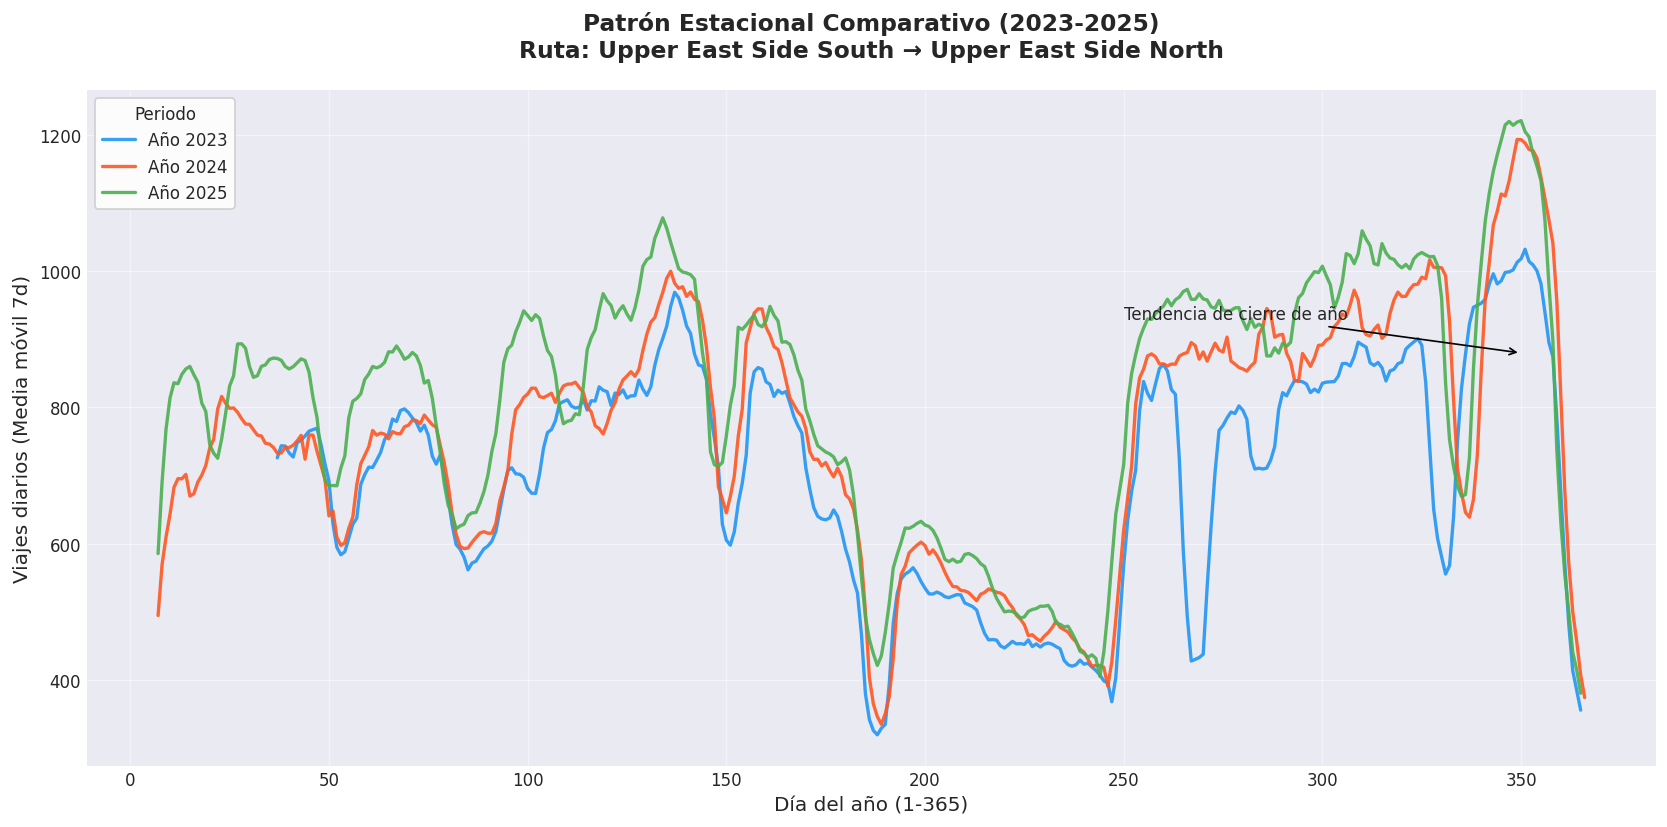

In [28]:
ZONE_NAMES = {132: 'JFK Airport', 138: 'LaGuardia Airport', 186: 'Penn Station / Madison Sq', 161: 'Midtown Center',
    162: 'Midtown East', 170: 'Murray Hill', 230: 'Times Sq / Theatre District', 142: 'Lincoln Square East',
    238: 'Upper West Side North', 239: 'Upper West Side South', 141: 'Lenox Hill East',  236: 'Upper East Side North', 
    237: 'Upper East Side South'
}

fig, ax = plt.subplots(figsize=(14, 7))
years = [2023, 2024, 2025]
line_colors = [PALETTE[0], PALETTE[1], PALETTE[2]]

# Iterar por cada año
pu, do = top_routes[0] 
route_data = daily[(daily['PULocationID'] == pu) & (daily['DOLocationID'] == do)].copy()

for year, color in zip(years, line_colors):
    year_data = route_data[route_data['pickup_date'].dt.year == year].copy()
    year_data['day_of_year'] = year_data['pickup_date'].dt.dayofyear
    
    # Media móvil de 7 días para limpiar el ruido
    smoothed_trips = year_data.set_index('day_of_year')['trips'].rolling(window=7).mean()
    
    # Graficamos
    ax.plot(smoothed_trips.index, smoothed_trips.values, 
            alpha=0.9, linewidth=2, label=f'Año {year}', color=color)

ax.set_title(f'Patrón Estacional Comparativo (2023-2025)\nRuta: {ZONE_NAMES.get(pu, "Desconocida")} → {ZONE_NAMES.get(do, "Desconocida")}', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Día del año (1-365)', fontsize=12)
ax.set_ylabel('Viajes diarios (Media móvil 7d)', fontsize=12)
ax.grid(True, linestyle='-', alpha=0.5)
ax.legend(title="Periodo", loc='upper left', frameon=True, facecolor='white', framealpha=0.9)

peak_avg = route_data[route_data['pickup_date'].dt.month == 12]['trips'].mean()
ax.annotate('Tendencia de cierre de año', xy=(350, peak_avg), 
            xytext=(250, peak_avg + 50),
            arrowprops=dict(arrowstyle="->", color='black'), fontsize=10)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/01_estacionalidad_comparativa.png', bbox_inches='tight', dpi=150)
plt.show()

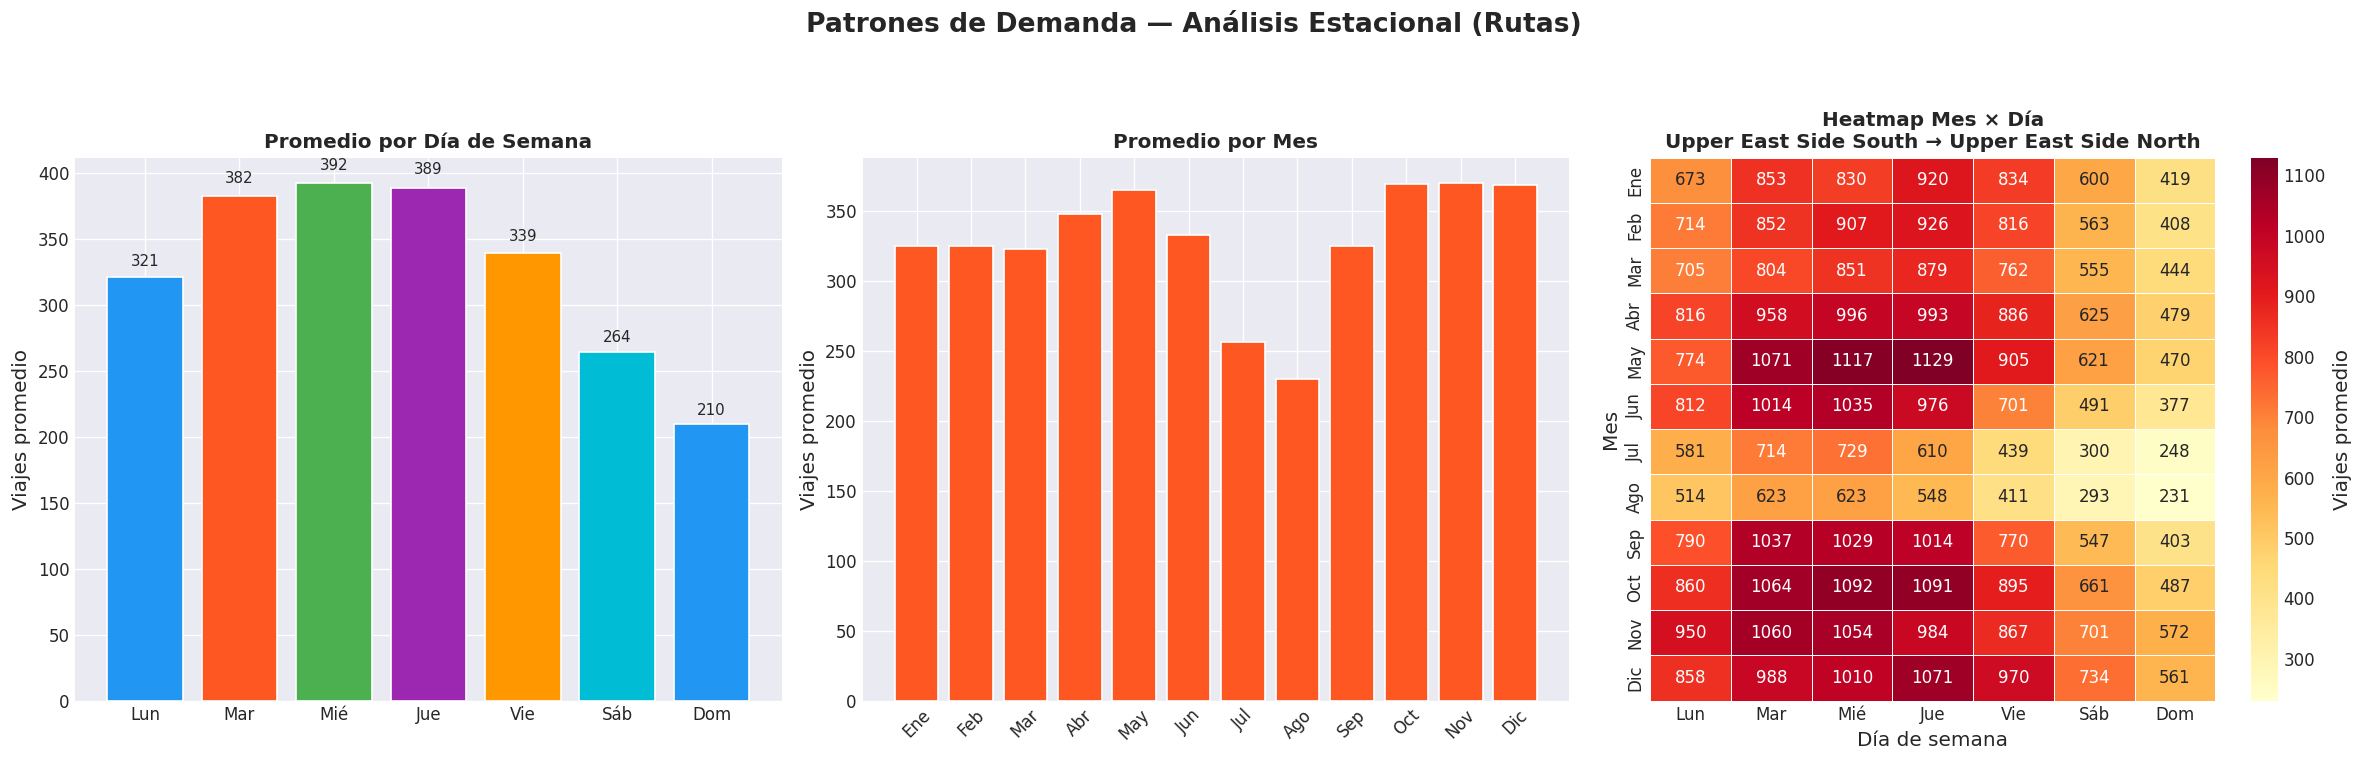

In [29]:
# Visualización de patrones estacionales globales y por ruta
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Patrones de Demanda — Análisis Estacional (Rutas)', fontsize=16, fontweight='bold', y=1.05)

# 1. Demanda por día de semana (Global)
dow_labels = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']
dow_avg = daily.groupby('dow')['trips'].mean()
axes[0].bar(dow_labels, dow_avg.values, color=PALETTE[:7], edgecolor='white', linewidth=1)
axes[0].set_title('Promedio por Día de Semana', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Viajes promedio')
for i, v in enumerate(dow_avg.values):
    axes[0].text(i, v + (v*0.02), f'{v:.0f}', ha='center', va='bottom', fontsize=9)

# 2. Demanda por mes (Global)
month_labels = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
month_avg = daily.groupby('month')['trips'].mean()
axes[1].bar(range(1,13), month_avg.values, color=PALETTE[1], edgecolor='white', linewidth=1)
axes[1].set_xticks(range(1,13))
axes[1].set_xticklabels(month_labels, rotation=45)
axes[1].set_title('Promedio por Mes', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Viajes promedio')

# 3. Heatmap: Mes × Día de semana (Para la primera ruta del Top)
pu, do = top_routes[0]
route_data = daily[(daily['PULocationID'] == pu) & (daily['DOLocationID'] == do)]
heat = route_data.groupby(['month', 'dow'])['trips'].mean().unstack()
heat.columns = dow_labels
heat.index = [month_labels[m-1] for m in heat.index]

sns.heatmap(heat, ax=axes[2], cmap='YlOrRd', annot=True, fmt='.0f', 
            linewidths=0.5, cbar_kws={'label': 'Viajes promedio'})
axes[2].set_title(f'Heatmap Mes × Día\n{ZONE_NAMES.get(pu, pu)} → {ZONE_NAMES.get(do, do)}', 
                  fontsize=12, fontweight='bold')
axes[2].set_xlabel('Día de semana')
axes[2].set_ylabel('Mes')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/02_patrones_demanda_estilo.png', bbox_inches='tight', dpi=150)
plt.show()

In [30]:
# Prueba de estacionariedad ADF por ruta
# Ajustamos el formato para incluir Origen y Destino
print(f'{"Ruta (Origen -> Destino)":<50} {"ADF Stat":>10} {"p-value":>10} {"Estac.":>10}')
print('─' * 85)

# Iteramos sobre las rutas únicas presentes en 'daily'
routes_list = daily[['PULocationID', 'DOLocationID']].drop_duplicates().values

for pu, do in routes_list:
    # Filtramos la serie de la ruta específica
    ts = daily[(daily['PULocationID'] == pu) & (daily['DOLocationID'] == do)]['trips'].values
    
    # Manejo de series cortas: el test ADF requiere un mínimo de datos
    if len(ts) < 10: 
        continue
        
    result = adfuller(ts, autolag='AIC')
    adf_stat, p_value = result[0], result[1]
    is_stationary = 'Sí' if p_value < 0.05 else 'No'
    pu_name = ZONE_NAMES.get(pu, f'Zone {pu}')
    do_name = ZONE_NAMES.get(do, f'Zone {do}')
    ruta_str = f"{pu_name} -> {do_name}"
    
    print(f'{ruta_str[:48]:<50} {adf_stat:>10.4f} {p_value:>10.4f} {is_stationary:>10}')

Ruta (Origen -> Destino)                             ADF Stat    p-value     Estac.
─────────────────────────────────────────────────────────────────────────────────────
JFK Airport -> Times Sq / Theatre District            -3.4883     0.0083         Sí
Lenox Hill East -> Upper East Side North              -4.1297     0.0009         Sí
Lincoln Square East -> Upper West Side South          -3.6628     0.0047         Sí
Midtown Center -> Upper East Side North               -4.3863     0.0003         Sí
Midtown Center -> Upper East Side South               -4.3005     0.0004         Sí
Midtown East -> Upper East Side South                 -5.3662     0.0000         Sí
Penn Station / Madison Sq -> Times Sq / Theatre       -3.9784     0.0015         Sí
Upper East Side North -> Lenox Hill East              -3.9558     0.0017         Sí
Upper East Side North -> Midtown Center               -5.0243     0.0000         Sí
Upper East Side North -> Upper East Side North        -4.1546     0.0008  

## **4. Desarrollo de los modelos**

In [31]:
# Creamos el ID de ruta único como texto para el One-Hot Encoding
daily['route_id_str'] = daily['PULocationID'].astype(str) + "_" + daily['DOLocationID'].astype(str)

# Codificación One-Hot de las rutas
daily_encoded = pd.get_dummies(daily, columns=['route_id_str'], drop_first=True, dtype=int)
route_dummy_cols = [c for c in daily_encoded.columns if c.startswith('route_id_str_')]

# Características globales que consumirán los modelos
GLOBAL_FEATURES = [
    'dow', 'month', 'week', 'day_of_year',
    'is_holiday', 'is_weekend',
    'lag_1', 'lag_7', 'lag_14', 'lag_30',
    'rolling_7_mean', 'rolling_7_std'
] + route_dummy_cols

TARGET_COL = 'trips_norm'

# División temporal
unique_dates = sorted(daily_encoded['pickup_date'].unique())
split_idx = int(len(unique_dates) * 0.8)
split_date = unique_dates[split_idx]

# Separación inicial antes de normalizar
train_global = daily_encoded[daily_encoded['pickup_date'] < split_date].copy()
test_global  = daily_encoded[daily_encoded['pickup_date'] >= split_date].copy()

# Calculamos la media y desviación estándar usando ÚNICAMENTE el set de entrenamiento por ruta
route_stats = train_global.groupby(['PULocationID', 'DOLocationID'])['trips'].agg(['mean', 'std']).reset_index()
# Por seguridad, evitamos divisiones por cero si una ruta tuviera desviación estándar cero
route_stats['std'] = route_stats['std'].replace(0, 1.0)

# Unimos estos estadísticos de entrenamiento a ambos conjuntos
train_global = train_global.merge(route_stats, on=['PULocationID', 'DOLocationID'], how='left')
test_global  = test_global.merge(route_stats, on=['PULocationID', 'DOLocationID'], how='left')

# Aplicamos la normalización estricta libre de fuga de datos
train_global['trips_norm'] = (train_global['trips'] - train_global['mean']) / train_global['std']
test_global['trips_norm'] = (test_global['trips'] - test_global['mean']) / test_global['std']

# Definición de X e y
X_train = train_global[GLOBAL_FEATURES]
y_train = train_global[TARGET_COL]
X_test  = test_global[GLOBAL_FEATURES]
y_test  = test_global[TARGET_COL]

print(f"Entrenando modelos globales con {len(X_train)} filas de entrenamiento y {len(X_test)} de prueba.")

# Entrenamiento de modelos
# Regresión lineal
global_lineal = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=10.0))
])
global_lineal.fit(X_train, y_train)

# Random Forest Global
global_rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=4,
    random_state=42,
    n_jobs=-1
)
global_rf.fit(X_train, y_train)

# XGBoost Global
global_xgb = XGBRegressor(
    n_estimators=150,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
global_xgb.fit(X_train, y_train)

Entrenando modelos globales con 17040 filas de entrenamiento y 4280 de prueba.


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [32]:
# generación de predicciones
test_eval = test_global.copy()
test_eval['pred_lineal'] = global_lineal.predict(X_test)
test_eval['pred_rf']    = global_rf.predict(X_test)
test_eval['pred_xgb']   = global_xgb.predict(X_test)

# Inicializamos las estructuras de almacenamiento antes del loop
all_results = []
predictions_store = {}

print("Evaluación de Modelos por Ruta (Escala de Negocio: Viajes Reales):")
print(f'{"Ruta":<35} | {"lineal R²":>10} | {"RF R²":>10} | {"XGB R²":>10} | {"RF MAE (Viajes)":>18}')
print("─" * 95)

routes_list = daily[['PULocationID', 'DOLocationID']].drop_duplicates().values

for pu, do in routes_list:
    route_test = test_eval[(test_eval['PULocationID'] == pu) & (test_eval['DOLocationID'] == do)]
    
    if len(route_test) == 0:
        continue
    
    stats_row = route_stats[(route_stats['PULocationID'] == pu) & (route_stats['DOLocationID'] == do)]
    if len(stats_row) == 0:
        continue
    mean_val = stats_row['mean'].values[0]
    std_val = stats_row['std'].values[0]
    
    # Valores reales y predicciones normalizadas
    y_true_norm = route_test[TARGET_COL].values
    y_pred_lineal_norm = route_test['pred_lineal'].values
    y_pred_rf_norm = route_test['pred_rf'].values
    y_pred_xgb_norm = route_test['pred_xgb'].values
    
    # Des-normalización a viajes reales
    y_true_real = route_test['trips'].values
    y_pred_lineal_real = np.maximum(y_pred_lineal_norm * std_val + mean_val, 0)
    y_pred_rf_real    = np.maximum(y_pred_rf_norm * std_val + mean_val, 0)
    y_pred_xgb_real   = np.maximum(y_pred_xgb_norm * std_val + mean_val, 0)
    
    # Cálculo de métricas individuales
    r2_lineal = r2_score(y_true_real, y_pred_lineal_real)
    r2_rf    = r2_score(y_true_real, y_pred_rf_real)
    r2_xgb   = r2_score(y_true_real, y_pred_xgb_real)
    
    mae_lineal = mean_absolute_error(y_true_real, y_pred_lineal_real)
    mae_rf    = mean_absolute_error(y_true_real, y_pred_rf_real)
    mae_xgb   = mean_absolute_error(y_true_real, y_pred_xgb_real)
    
    rmse_lineal = np.sqrt(mean_squared_error(y_true_real, y_pred_lineal_real))
    rmse_rf    = np.sqrt(mean_squared_error(y_true_real, y_pred_rf_real))
    rmse_xgb   = np.sqrt(mean_squared_error(y_true_real, y_pred_xgb_real))
    
    # Identificador único de ruta
    route_key = f"{pu}_{do}"
    
    # 1. Guardar métricas en all_results
    all_results.append({'zone_id': route_key, 'model': 'lineal', 'RMSE': rmse_lineal, 'MAE': mae_lineal, 'R2': r2_lineal})
    all_results.append({'zone_id': route_key, 'model': 'RandomForest', 'RMSE': rmse_rf, 'MAE': mae_rf, 'R2': r2_rf})
    all_results.append({'zone_id': route_key, 'model': 'XGBoost', 'RMSE': rmse_xgb, 'MAE': mae_xgb, 'R2': r2_xgb})
    
    # 2. Guardar predicciones en predictions_store para graficar
    predictions_store[(route_key, 'lineal')] = {'dates': route_test['pickup_date'].values, 'y_true': y_true_real, 'y_pred': y_pred_lineal_real}
    predictions_store[(route_key, 'RandomForest')] = {'dates': route_test['pickup_date'].values, 'y_true': y_true_real, 'y_pred': y_pred_rf_real}
    predictions_store[(route_key, 'XGBoost')] = {'dates': route_test['pickup_date'].values, 'y_true': y_true_real, 'y_pred': y_pred_xgb_real}
    
    # Imprimir en consola
    pu_name = ZONE_NAMES.get(pu, f'Zone {pu}')
    do_name = ZONE_NAMES.get(do, f'Zone {do}')
    ruta_label = f"{pu_name[:14]} -> {do_name[:14]}"
    print(f'{ruta_label:<35} | {r2_lineal:>10.3f} | {r2_rf:>10.3f} | {r2_xgb:>10.3f} | {mae_rf:>15.1f} v/día')

Evaluación de Modelos por Ruta (Escala de Negocio: Viajes Reales):
Ruta                                |  lineal R² |      RF R² |     XGB R² |    RF MAE (Viajes)
───────────────────────────────────────────────────────────────────────────────────────────────
JFK Airport -> Times Sq / The       |      0.237 |      0.150 |      0.228 |            33.6 v/día
Lenox Hill Eas -> Upper East Sid    |      0.558 |      0.782 |      0.791 |            27.5 v/día
Lincoln Square -> Upper West Sid    |      0.449 |      0.698 |      0.776 |            30.5 v/día
Midtown Center -> Upper East Sid    |      0.751 |      0.778 |      0.799 |            43.3 v/día
Midtown Center -> Upper East Sid    |      0.733 |      0.686 |      0.739 |            61.4 v/día
Midtown East -> Upper East Sid      |      0.686 |      0.779 |      0.838 |            32.8 v/día
Penn Station / -> Times Sq / The    |      0.292 |      0.304 |      0.426 |            35.4 v/día
Upper East Sid -> Lenox Hill Eas    |      0.597

## **5. Comparación de Modelos y Métricas**

In [33]:
# Convierte la lista de resultados en un DataFrame
results_df = pd.DataFrame(all_results)

# Limpieza básica por si hay valores nulos o tipos incorrectos
results_df['RMSE'] = pd.to_numeric(results_df['RMSE'], errors='coerce')
results_df['MAE'] = pd.to_numeric(results_df['MAE'], errors='coerce')
results_df['R2'] = pd.to_numeric(results_df['R2'], errors='coerce')
comparison_table = results_df.groupby('model')[['RMSE', 'MAE', 'R2']].mean()
comparison_table = comparison_table.reset_index()

display(
    comparison_table.sort_values('R2', ascending=False)
    .style
    .background_gradient(subset=['RMSE', 'MAE'], cmap='RdYlGn_r')
    .background_gradient(subset=['R2'], cmap='RdYlGn')
    .format({'RMSE': '{:.2f}', 'MAE': '{:.2f}', 'R2': '{:.4f}'})
    .hide(axis='index') # Opcional: oculta el índice numérico automático de Pandas
)

model,RMSE,MAE,R2
XGBoost,50.35,38.81,0.7537
RandomForest,56.60,43.87,0.7031
lineal,71.66,56.25,0.5637


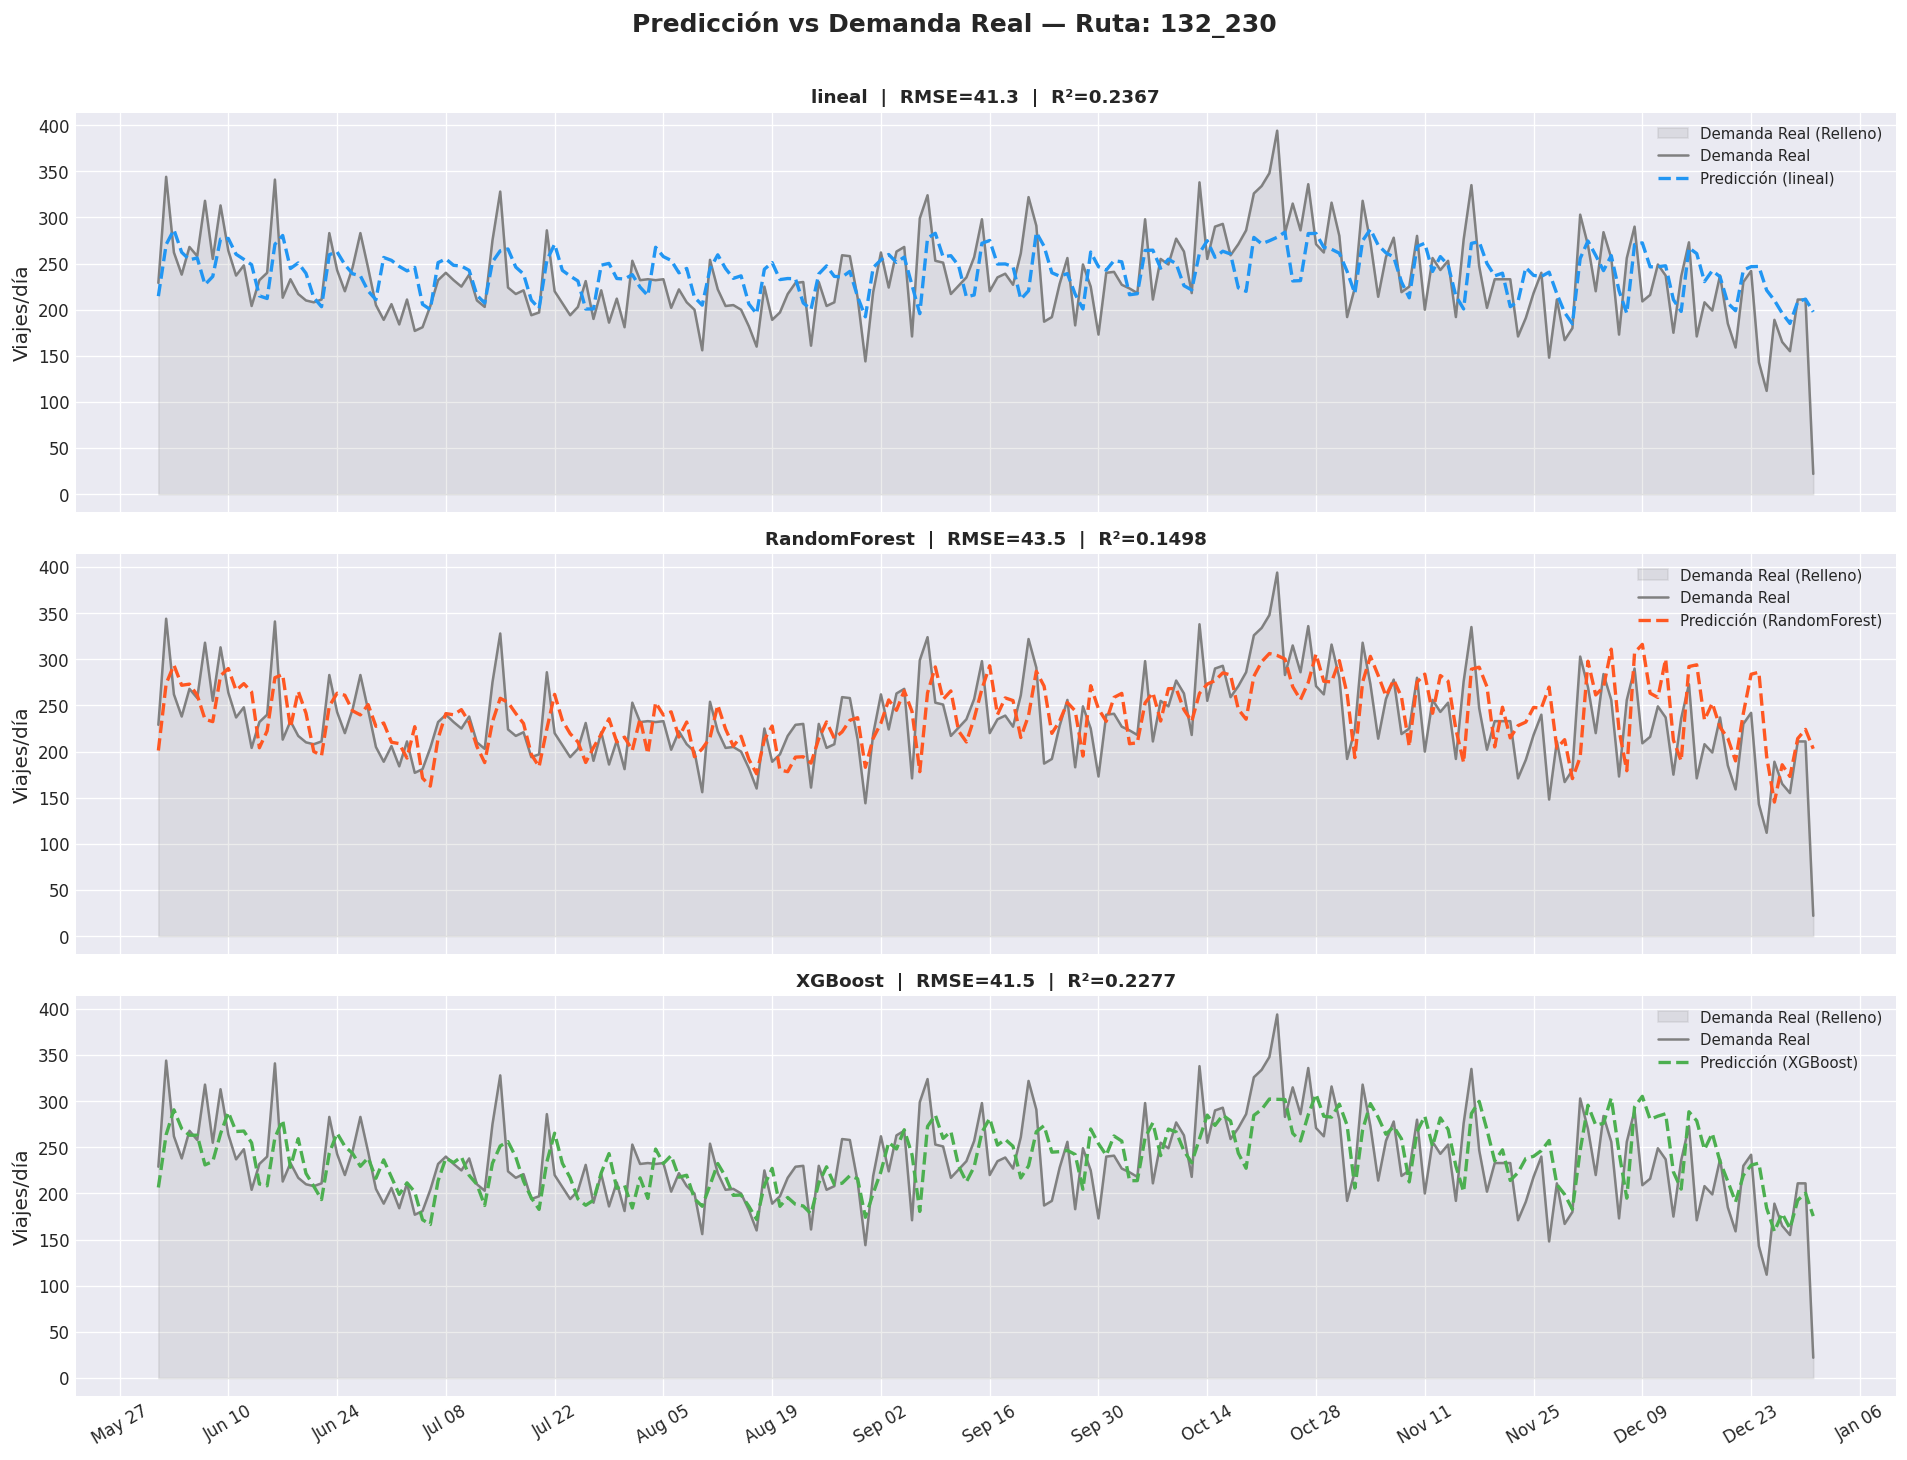

In [34]:
MODELS_TO_PLOT = ['lineal', 'RandomForest', 'XGBoost']
MODEL_COLORS   = dict(zip(MODELS_TO_PLOT, PALETTE[:3])) 
PRIMARY_ROUTE = results_df['zone_id'].iloc[0]  # Usamos la primera ruta del top como ejemplo

fig, axes = plt.subplots(len(MODELS_TO_PLOT), 1, figsize=(16, 4 * len(MODELS_TO_PLOT)), sharex=True)

if len(MODELS_TO_PLOT) == 1:
    axes = [axes]

fig.suptitle(
    f'Predicción vs Demanda Real — Ruta: {PRIMARY_ROUTE}',
    fontsize=15, fontweight='bold', y=1.01
)

for ax, model_name in zip(axes, MODELS_TO_PLOT):
    key = (PRIMARY_ROUTE, model_name)
    if key not in predictions_store:
        ax.text(0.5, 0.5, f"Sin datos para {model_name} en la ruta {PRIMARY_ROUTE}", 
                ha='center', va='center', transform=ax.transAxes, color='gray', fontsize=12)
        continue

    preds = predictions_store[key]
    dates  = pd.to_datetime(preds['dates'])
    y_true = preds['y_true']
    y_pred = preds['y_pred']

    # Extraer métricas específicas de esta ruta y modelo
    m_row = results_df[(results_df['model'] == model_name) & (results_df['zone_id'] == PRIMARY_ROUTE)]
    rmse_val = m_row['RMSE'].values[0] if len(m_row) > 0 else 0
    r2_val   = m_row['R2'].values[0]   if len(m_row) > 0 else 0

    # Dibujar la demanda real y la predicción
    ax.fill_between(dates, y_true, alpha=0.15, color='gray', label='Demanda Real (Relleno)')
    ax.plot(dates, y_true, color='gray', linewidth=1.5, label='Demanda Real')
    ax.plot(dates, y_pred, color=MODEL_COLORS[model_name], linewidth=2,
            linestyle='--', label=f'Predicción ({model_name})')

    ax.set_title(f'{model_name}  |  RMSE={rmse_val:.1f}  |  R²={r2_val:.4f}',
                 fontsize=11, fontweight='bold')
    ax.set_ylabel('Viajes/día')
    ax.legend(loc='upper right', fontsize=9)
    
    # Formato de fechas en el eje X
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/03_pred_vs_real.png', bbox_inches='tight', dpi=150)
plt.show()

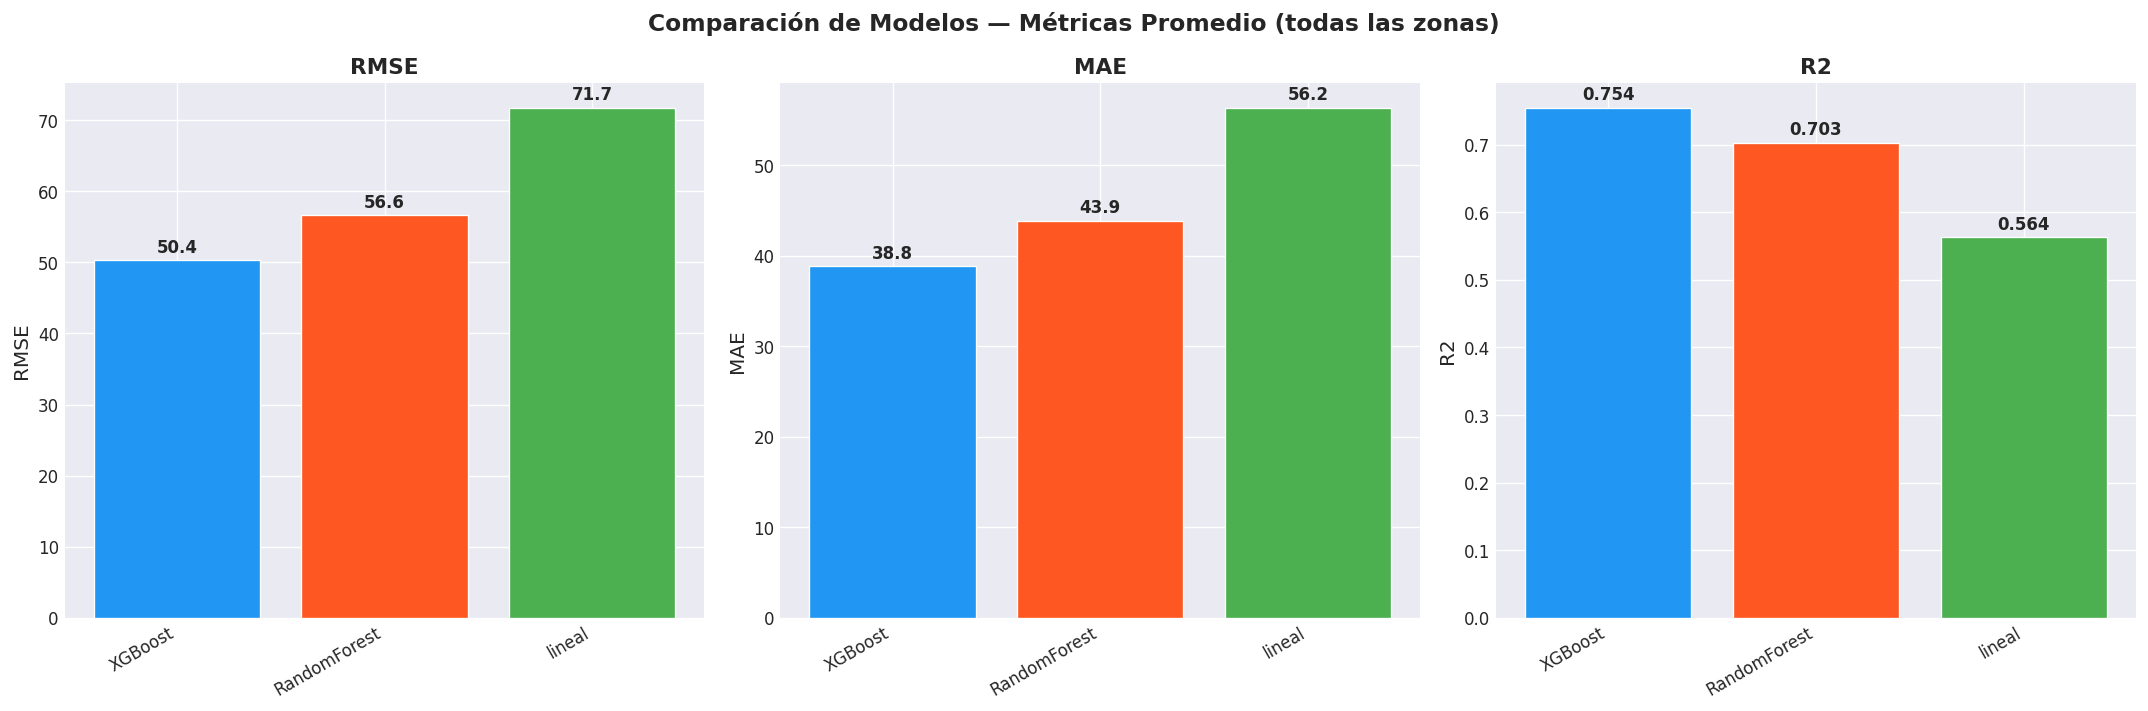

In [35]:
# Comparativa visual de métricas promedio por modelo
avg_metrics = results_df.groupby('model')[['RMSE', 'MAE', 'R2']].mean().sort_values('RMSE')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Comparación de Modelos — Métricas Promedio (todas las zonas)',
             fontsize=14, fontweight='bold')

for ax, (metric, color_map) in zip(axes, [('RMSE', PALETTE[1]), ('MAE', PALETTE[0]), ('R2', PALETTE[2])]):
    bars = ax.bar(
        avg_metrics.index,
        avg_metrics[metric],
        color=[PALETTE[i % len(PALETTE)] for i in range(len(avg_metrics))],
        edgecolor='white', linewidth=0.8
    )
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_ylabel(metric)
    ax.set_xticklabels(avg_metrics.index, rotation=30, ha='right')
    for bar, val in zip(bars, avg_metrics[metric].values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01*bar.get_height(),
                f'{val:.1f}' if metric != 'R2' else f'{val:.3f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/04_model_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

## **6. Predicción Final: Próximos 30 Días**

In [36]:
# Configuración del horizonte de predicción (Enero 2026)
FORECAST_DAYS = 30
forecast_dates = pd.date_range(start='2026-01-01', periods=FORECAST_DAYS, freq='D')
us_holidays_2026 = holidays.US(state='NY', years=[2026])

# Seleccionamos XGBoost como nuestro modelo campeón
champion_model = global_xgb 

forecast_results = []

# Iteramos de forma independiente por cada una de las rutas
for (pu, do), group in daily_encoded.groupby(['PULocationID', 'DOLocationID']):
    
    # Obtener la media y desviación estándar histórica para des-normalizar
    stats_row = route_stats[(route_stats['PULocationID'] == pu) & (route_stats['DOLocationID'] == do)]
    if len(stats_row) == 0:
        continue
    mean_val = stats_row['mean'].values[0]
    std_val = stats_row['std'].values[0]
    
    # 2. Extraer el historial más reciente (últimos 30 días de 2025) para alimentar los primeros lags
    history = group.sort_values('pickup_date').tail(30).copy()
    
    # 3. Crear las filas vacías para las fechas futuras de Enero 2026
    future_df = pd.DataFrame(index=forecast_dates)
    future_df.index.name = 'pickup_date'
    future_df = future_df.reset_index()
    
    future_df['PULocationID'] = pu
    future_df['DOLocationID'] = do
    future_df['trips'] = np.nan  # Se irá llenando dinámicamente paso a paso
    
    # Copiar de forma estática las columnas de One-Hot Encoding que identifican a esta ruta
    for col in route_dummy_cols:
        future_df[col] = history[col].iloc[0]
        
    # Concatenar historia reciente y el futuro vacío
    combined = pd.concat([history, future_df], ignore_index=True)
    
    # 4. Proceso recursivo día por día
    for i in range(len(history), len(combined)):
        current_date = combined.loc[i, 'pickup_date']
        
        # a. Calcular variables de calendario para el día futuro actual
        combined.loc[i, 'dow'] = current_date.dayofweek
        combined.loc[i, 'month'] = current_date.month
        combined.loc[i, 'week'] = int(current_date.isocalendar().week)
        combined.loc[i, 'day_of_year'] = current_date.dayofyear
        combined.loc[i, 'is_weekend'] = 1 if current_date.dayofweek >= 5 else 0
        combined.loc[i, 'is_holiday'] = 1 if current_date in us_holidays_2026 else 0
        
        # b. Asignar Lags basados en los valores (reales o ya predichos) del pasado inmediato
        combined.loc[i, 'lag_1']  = combined.loc[i - 1, 'trips']
        combined.loc[i, 'lag_7']  = combined.loc[i - 7, 'trips']
        combined.loc[i, 'lag_14'] = combined.loc[i - 14, 'trips']
        combined.loc[i, 'lag_30'] = combined.loc[i - 30, 'trips']
        
        # c. Calcular estadísticas móviles (excluyendo el día actual)
        rolling_7_window = combined.loc[i-7:i-1, 'trips']
        combined.loc[i, 'rolling_7_mean'] = rolling_7_window.mean()
        combined.loc[i, 'rolling_7_std']  = np.nan_to_num(rolling_7_window.std(), nan=0.0)
        
        # d. Aislar el vector de características para pasarlo al modelo
        X_step = combined.loc[[i], GLOBAL_FEATURES]
        
        # e. Predicción normalizada (Z-score)
        pred_norm = champion_model.predict(X_step)[0]
        
        # f. Des-normalizar a viajes reales y asegurar que no haya valores negativos
        pred_real = np.maximum(pred_norm * std_val + mean_val, 0)
        
        # g. Guardar el resultado para que sirva como lag en las iteraciones futuras
        combined.loc[i, 'trips'] = pred_real
        
    # Extraer únicamente el segmento proyectado de 30 días
    forecast_route = combined.tail(FORECAST_DAYS).copy()
    forecast_results.append(forecast_route)

# 5. Consolidar el dataframe final de proyecciones
forecast_all = pd.concat(forecast_results, ignore_index=True)
print(f"Proyección recursiva de 30 días completada exitosamente")
print(f"Tamaño del dataset de forecast: {forecast_all.shape}")

Proyección recursiva de 30 días completada exitosamente
Tamaño del dataset de forecast: (600, 37)


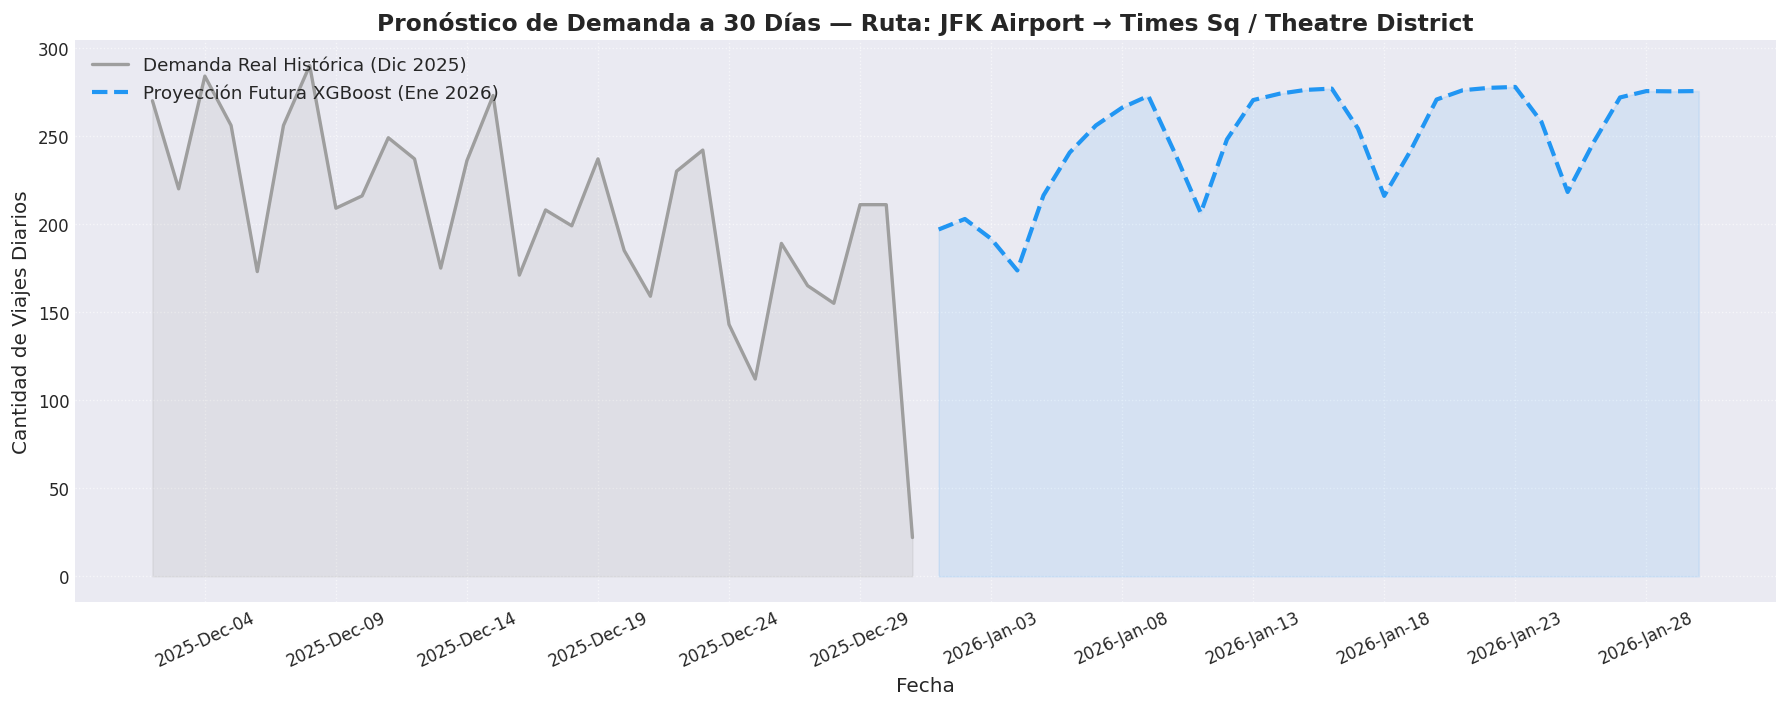

In [37]:
ROUTE_TO_PLOT = results_df['zone_id'].iloc[0]  # Usamos la primera ruta del top como ejemplo

pu_id, do_id = map(int, ROUTE_TO_PLOT.split('_'))

# 1. Obtener la historia real (Diciembre 2025)
history_real = daily_encoded[
    (daily_encoded['PULocationID'] == pu_id) & 
    (daily_encoded['DOLocationID'] == do_id)
].sort_values('pickup_date').tail(30)

# 2. Obtener el forecast generado (Enero 2026)
forecast_route = forecast_all[
    (forecast_all['PULocationID'] == pu_id) & 
    (forecast_all['DOLocationID'] == do_id)
]

plt.figure(figsize=(15, 6))

# Graficar Historia Real
plt.plot(history_real['pickup_date'], history_real['trips'], 
         color='#9E9E9E', linewidth=2, label='Demanda Real Histórica (Dic 2025)')
plt.fill_between(history_real['pickup_date'], history_real['trips'], 
                 color='#9E9E9E', alpha=0.15)

# Graficar Proyección Futura (XGBoost)
plt.plot(forecast_route['pickup_date'], forecast_route['trips'], 
         color='#2196F3', linewidth=2.5, linestyle='--', 
         label='Proyección Futura XGBoost (Ene 2026)')
plt.fill_between(forecast_route['pickup_date'], forecast_route['trips'], 
                 color='#2196F3', alpha=0.1)

# Formatear el gráfico
pu_name = ZONE_NAMES.get(pu_id, f'Zone {pu_id}')
do_name = ZONE_NAMES.get(do_id, f'Zone {do_id}')
plt.title(f'Pronóstico de Demanda a 30 Días — Ruta: {pu_name} → {do_name}', 
          fontsize=14, fontweight='bold')
plt.ylabel('Cantidad de Viajes Diarios', fontsize=12)
plt.xlabel('Fecha', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper left', fontsize=11)

# Ajuste del eje del tiempo para mostrar la transición de año de forma clara
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%b-%d'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=5))
plt.xticks(rotation=25)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/05_forecast.png', bbox_inches='tight', dpi=150)
plt.show()

## **7. Resumen operacional**

In [38]:
# Resumen operacional para las rutas evaluadas
print('\nRESUMEN OPERACIONAL — Demanda Pronosticada (30 días)')
print('Para planificación de flota y personal\n')

PASSENGERS_PER_VEHICLE = 4   # promedio de ocupación
TRIPS_PER_DRIVER_DAY   = 25  # viajes promedio por conductor/día

summary_rows = []

# Iteramos de forma segura por las rutas que procesamos
for pu, do in routes_list:
    route_key = f"{pu}_{do}"
    
    # Filtrar la predicción generada para esta ruta
    fc = forecast_all[(forecast_all['PULocationID'] == pu) & (forecast_all['DOLocationID'] == do)]
    if len(fc) == 0:
        continue
        
    # Extraemos métricas basadas en 'trips' (viajes reales pronosticados)
    avg_daily  = fc['trips'].mean()
    peak_daily = fc['trips'].max()
    low_daily  = fc['trips'].min()
    total_30   = fc['trips'].sum()
    
    # Estimación de requerimientos operativos
    vehicles_needed = int(np.ceil(peak_daily / TRIPS_PER_DRIVER_DAY))
    drivers_needed  = vehicles_needed

    # Formatear nombres de origen y destino para la tabla
    pu_name = ZONE_NAMES.get(pu, f'Zone {pu}')[:14]
    do_name = ZONE_NAMES.get(do, f'Zone {do}')[:14]
    ruta_label = f"{pu_name} -> {do_name}"

    summary_rows.append({
        'Ruta':           ruta_label,
        'Prom. diario':   f'{avg_daily:.1f}',
        'Pico diario':    f'{peak_daily:.1f}',
        'Mínimo diario':  f'{low_daily:.1f}',
        'Total 30 días':  f'{total_30:.0f}',
        'Vehículos peak': vehicles_needed,
        'Conductores':    drivers_needed,
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df.style.set_properties(**{'text-align': 'center'}))


RESUMEN OPERACIONAL — Demanda Pronosticada (30 días)
Para planificación de flota y personal



,Ruta,Prom. diario,Pico diario,Mínimo diario,Total 30 días,Vehículos peak,Conductores
0,JFK Airport -> Times Sq / The,248.1,277.9,173.7,7444,12,12
1,Lenox Hill Eas -> Upper East Sid,243.6,283.4,175.1,7309,12,12
2,Lincoln Square -> Upper West Sid,292.4,337.7,234.5,8771,14,14
3,Midtown Center -> Upper East Sid,313.1,413.7,179.8,9393,17,17
4,Midtown Center -> Upper East Sid,370.3,484.2,201.0,11109,20,20
5,Midtown East -> Upper East Sid,172.0,235.1,87.2,5160,10,10
6,Penn Station / -> Times Sq / The,244.5,272.9,188.9,7336,11,11
7,Upper East Sid -> Lenox Hill Eas,235.4,295.2,146.0,7061,12,12
8,Upper East Sid -> Midtown Center,234.7,335.2,84.8,7041,14,14
9,Upper East Sid -> Upper East Sid,500.5,629.8,260.3,15014,26,26


## **8. Guardado de Modelos y Exportación de Resultados**

In [39]:
# Guardar el modelo de XGBoost en su formato nativo JSON
model_path = MODELS_DIR / 'best_xgboost_model.json'
global_xgb.save_model(str(model_path))
print(f" Modelo XGBoost guardado en: {model_path}")

# Extraer el historial semilla (últimos 30 días reales de 2025) para que la web pueda calcular los primeros lags del forecast recursivo
latest_history = daily_encoded.sort_values('pickup_date').groupby(['PULocationID', 'DOLocationID']).tail(30).copy()

# Empacar todos los metadatos necesarios en un solo diccionario
artifacts = {
    'route_stats': route_stats,             # Estadísticos de media/std por ruta
    'latest_history': latest_history,       # Dataset semilla de diciembre 2025
    'GLOBAL_FEATURES': GLOBAL_FEATURES,     # Columnas de entrada exactas que espera el modelo
    'route_dummy_cols': route_dummy_cols,   # Columnas de One-Hot Encoding de las rutas
    'ZONE_NAMES': ZONE_NAMES                # Diccionario de nombres de las zonas
}

# Guardar los artefactos en un archivo Pickle
artifacts_path = MODELS_DIR / 'model_artifacts.pkl'
with open(artifacts_path, 'wb') as f:
    pickle.dump(artifacts, f)
    
print(f"Artefactos de despliegue guardados en: {artifacts_path}")

 Modelo XGBoost guardado en: c:\Users\USUARIO\Documents\Clases\2026_1\RNA y Algo. Bioinsp\RNAAB_T03\output\modulo1\models\best_xgboost_model.json
Artefactos de despliegue guardados en: c:\Users\USUARIO\Documents\Clases\2026_1\RNA y Algo. Bioinsp\RNAAB_T03\output\modulo1\models\model_artifacts.pkl
